In [18]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
file_path = '../datasets/giuriati_2/20170621_deg0_HHVV.npy'

In [3]:
dataset = np.load(file_path, allow_pickle=True).item()

In [7]:
data = dataset['data']
gt = dataset['ground_truth']

In [13]:
print("-" * 40)
print(f"Вміст словника (ключі): {list(dataset.keys())}")
print(f"Розмірність матриці даних (Shape): {np.shape(data)}")
print(f"Розмірність розмітки (Ground Truth): {np.shape(gt)}")
print(f"Мінімальне значення: {data.min():.4f}")
print(f"Максимальне значення: {data.max():.4f}")
print("-" * 40)

----------------------------------------
Вміст словника (ключі): ['param', 'data', 'ground_truth']
Розмірність матриці даних (Shape): (66, 170, 440)
Розмірність розмітки (Ground Truth): (66,)
Мінімальне значення: -2.6768
Максимальне значення: 3.0877
----------------------------------------


In [31]:
data.shape == (66, 170, 440), gt.shape == (66,)

(True, True)

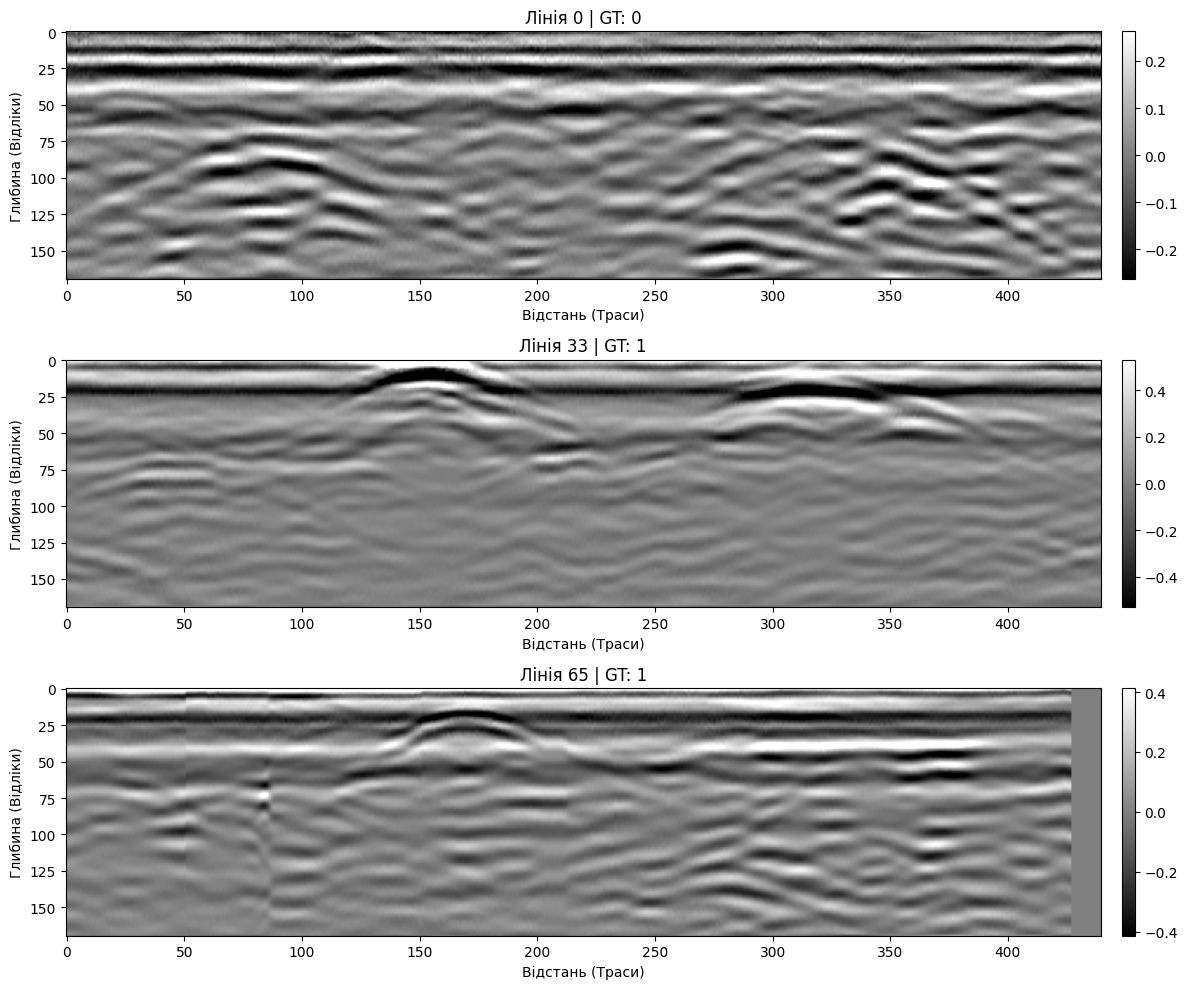

In [53]:
lines_to_plot = [0, 33, 65]

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for i, line_idx in enumerate(lines_to_plot):
    b_scan = data[line_idx]

    # Розраховуємо ліміти для контрасту
    vmax = np.percentile(np.abs(b_scan), 98)

    # aspect='auto' дозволяє зображенню розтягуватись під розмір вікна (робить прямокутним)
    im = axes[i].imshow(b_scan, cmap='gray', aspect='auto', vmin=-vmax, vmax=vmax)

    axes[i].set_title(f"Лінія {line_idx} | GT: {gt[line_idx]}")
    axes[i].set_xlabel("Відстань (Траси)")
    axes[i].set_ylabel("Глибина (Відліки)")

    # Додаємо кольорову шкалу до кожного графіка
    fig.colorbar(im, ax=axes[i], fraction=0.02, pad=0.02)

# Автоматично вирівнює відступи, щоб графіки не налізали один на одного
plt.tight_layout()
plt.show()

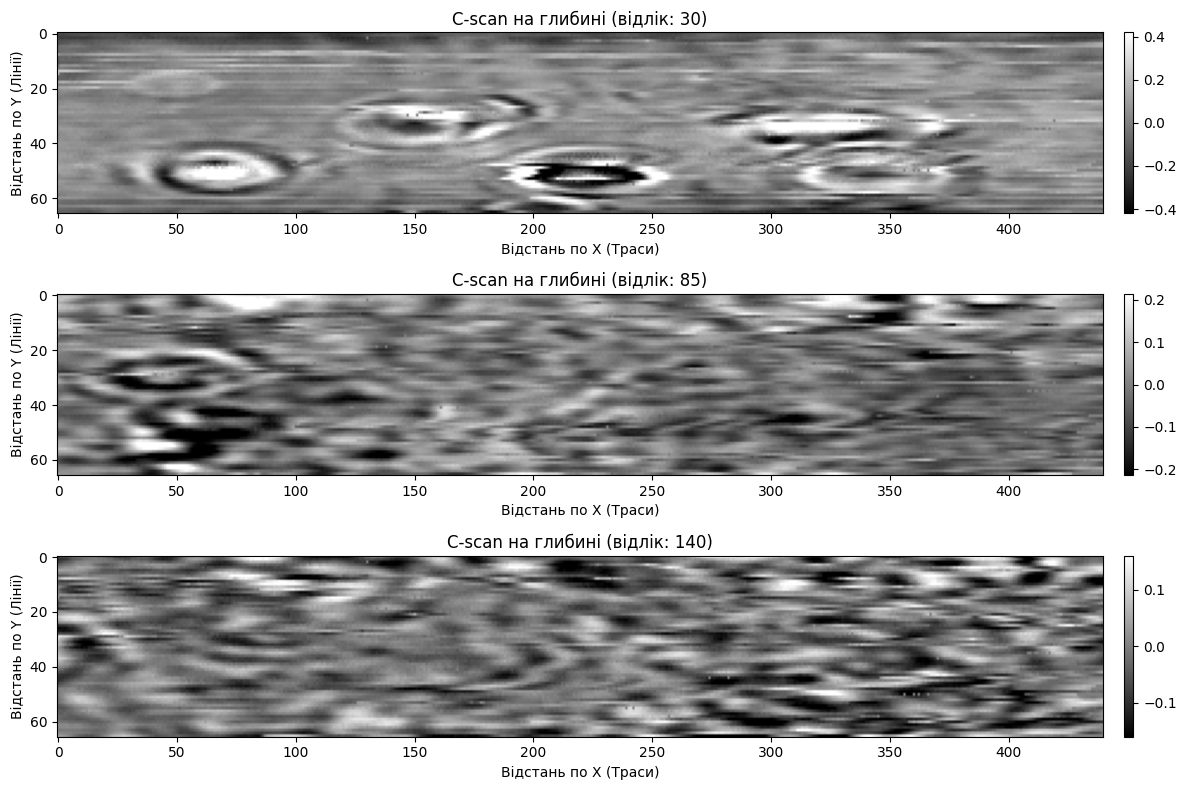

In [52]:
depths_to_plot = [30, 85, 140]

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for i, depth_idx in enumerate(depths_to_plot):
    # Витягуємо C-scan: беремо всі 66 ліній (:), фіксовану глибину, і всі 440 трас (:)
    # Розмірність c_scan буде (66, 440)
    c_scan = data[:, depth_idx, :]

    # Розраховуємо ліміти контрасту для конкретного зрізу
    vmax = np.percentile(np.abs(c_scan), 98)

    # Відображаємо. Вісь Y - це рух радара між лініями (0-66),
    # вісь X - це рух радара вздовж однієї лінії (0-440).
    im = axes[i].imshow(c_scan, cmap='gray', aspect='auto', vmin=-vmax, vmax=vmax)

    axes[i].set_title(f"C-scan на глибині (відлік: {depth_idx})")
    axes[i].set_xlabel("Відстань по X (Траси)")
    axes[i].set_ylabel("Відстань по Y (Лінії)")

    # Додаємо кольорову шкалу
    fig.colorbar(im, ax=axes[i], fraction=0.02, pad=0.02)

plt.tight_layout()
plt.show()

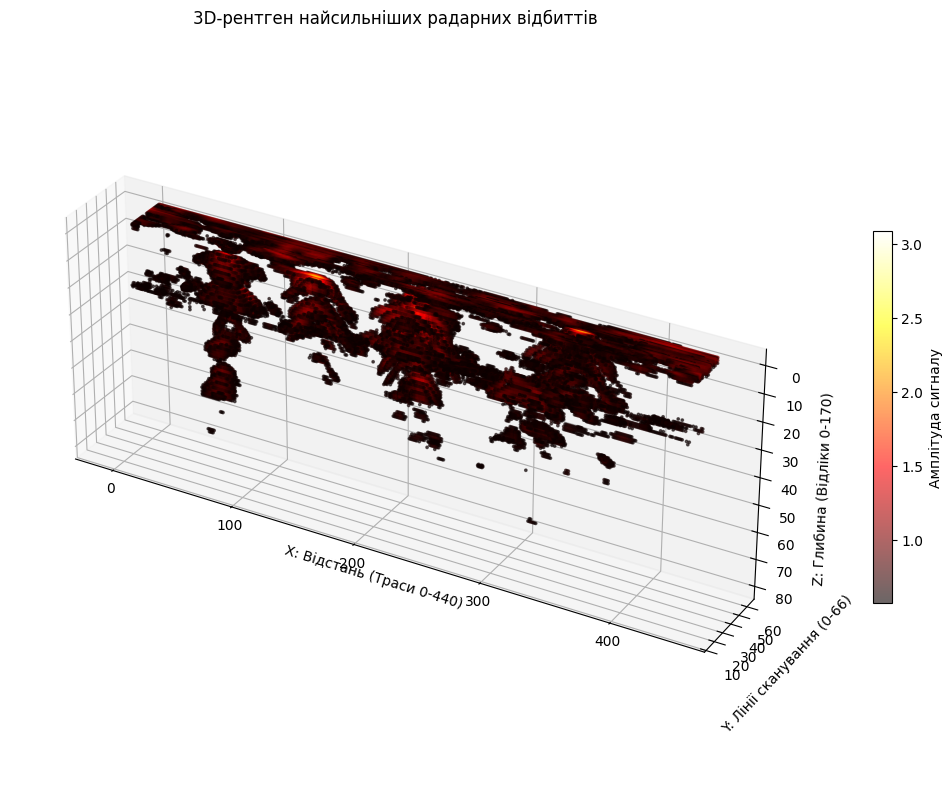

In [56]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Обчислюємо поріг: беремо лише 1% найвищих за модулем значень (аномалії)
threshold = np.percentile(np.abs(data), 99)

# Знаходимо координати всіх точок, які перевищують цей поріг
# Оскільки data має форму (66 лінії, 170 глибина, 440 траси):
y_idx, z_idx, x_idx = np.where(np.abs(data) > threshold)

# Витягуємо самі значення амплітуд для цих точок (щоб розфарбувати їх)
amplitudes = np.abs(data[y_idx, z_idx, x_idx])

# Будуємо 3D scatter plot (точкову діаграму)
# s=3 - розмір точки, alpha=0.6 - робить їх трохи прозорими
scatter = ax.scatter(x_idx, y_idx, z_idx, c=amplitudes, cmap='hot', s=3, alpha=0.6)

# Налаштовуємо осі
ax.set_title("3D-рентген найсильніших радарних відбиттів")
ax.set_xlabel("X: Відстань (Траси 0-440)")
ax.set_ylabel("Y: Лінії сканування (0-66)")
ax.set_zlabel("Z: Глибина (Відліки 0-170)")

# Важливий крок: розвертаємо вісь Z, щоб поверхня (0) була зверху, а сигнал йшов униз
ax.invert_zaxis()

# (Опціонально) Задаємо пропорції коробки графіка, щоб вони відповідали реальним розмірам матриці
try:
    ax.set_box_aspect((440, 66, 170))
except AttributeError:
    pass # Для старіших версій matplotlib, які не підтримують box_aspect

# Додаємо кольорову шкалу
fig.colorbar(scatter, ax=ax, fraction=0.02, pad=0.1, label='Амплітуда сигналу')

plt.show()

In [57]:
line_idx = 33
b_scan_raw = data[line_idx].copy()

# ==========================================
# КРОК 1: Видалення фону (Background Removal)
# ==========================================
# Рахуємо середню трасу (середнє по осі 1 - по горизонталі)
mean_trace = np.mean(b_scan_raw, axis=1, keepdims=True)
# Віднімаємо середню трасу від усього масиву
b_scan_bg_removed = b_scan_raw - mean_trace

# ==========================================
# КРОК 2: Компенсація загасання (Time-Varying Gain)
# ==========================================
# Задаємо емпіричний коефіцієнт згасання. Його можна підбирати (0.01 - 0.03).
alpha = 0.015
depth_indices = np.arange(b_scan_raw.shape[0]) # від 0 до 169
# Формуємо матрицю підсилення (170, 1) для множення на кожен стовпець
gain_curve = np.exp(alpha * depth_indices).reshape(-1, 1)

b_scan_tvg = b_scan_bg_removed * gain_curve

# ==========================================
# КРОК 3: М'яка Нормалізація (Soft Normalization)
# ==========================================
# Нормалізуємо до діапазону [-1, 1] шляхом ділення на максимальне абсолютне значення
max_val = np.max(np.abs(b_scan_tvg))
b_scan_norm = b_scan_tvg / max_val

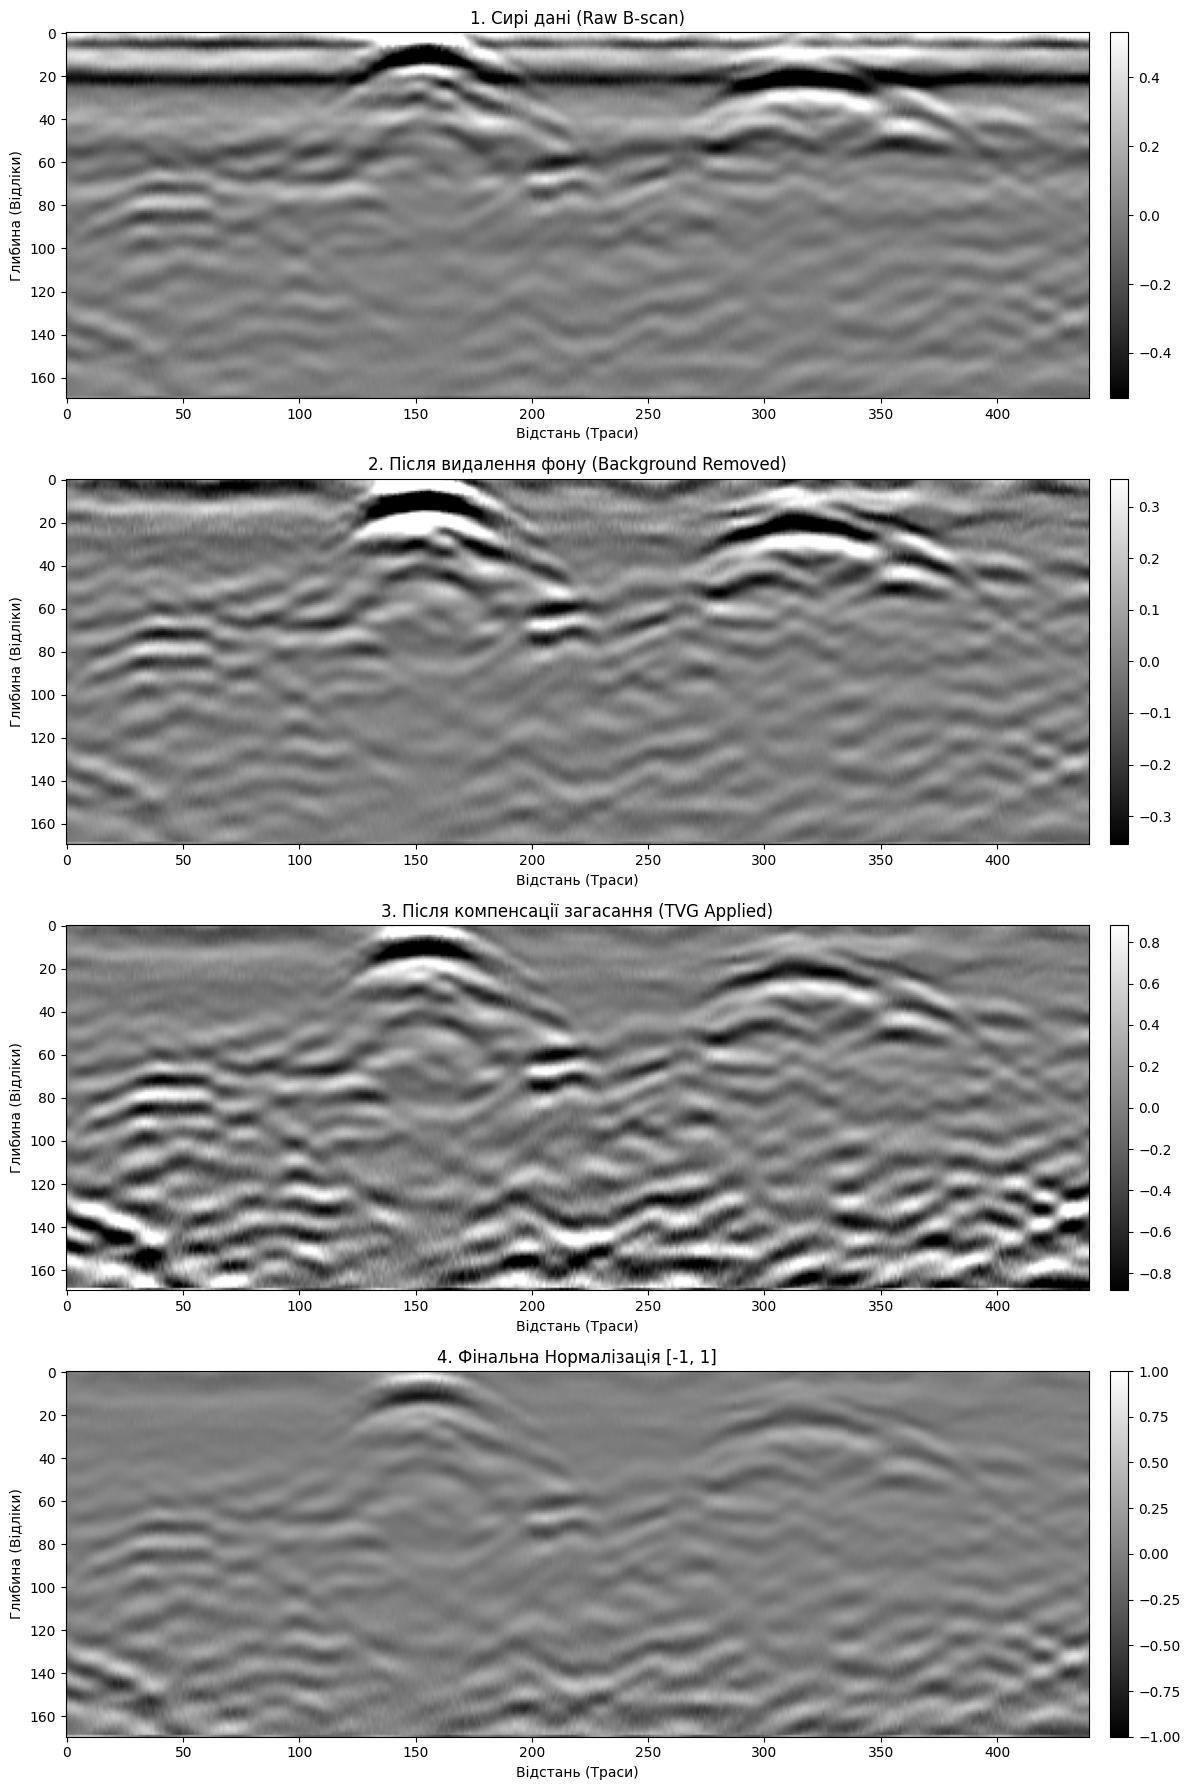

In [58]:
# ==========================================
# ВІЗУАЛІЗАЦІЯ ЕТАПІВ
# ==========================================
fig, axes = plt.subplots(4, 1, figsize=(12, 18))

# Словник з етапами для зручного виводу у циклі
stages = [
    ("1. Сирі дані (Raw B-scan)", b_scan_raw),
    ("2. Після видалення фону (Background Removed)", b_scan_bg_removed),
    ("3. Після компенсації загасання (TVG Applied)", b_scan_tvg),
    ("4. Фінальна Нормалізація [-1, 1]", b_scan_norm)
]

for i, (title, scan_data) in enumerate(stages):
    # Використовуємо 98-й перцентиль для контрасту, окрім останнього графіка,
    # де ми хочемо побачити чесні нормалізовані значення
    if i < 3:
        vmax = np.percentile(np.abs(scan_data), 98)
    else:
        vmax = 1.0 # Для нормалізованих даних ліміт завжди 1

    im = axes[i].imshow(scan_data, cmap='gray', aspect='auto', vmin=-vmax, vmax=vmax)
    axes[i].set_title(title)
    axes[i].set_xlabel("Відстань (Траси)")
    axes[i].set_ylabel("Глибина (Відліки)")
    fig.colorbar(im, ax=axes[i], fraction=0.02, pad=0.02)

plt.tight_layout()
plt.show()

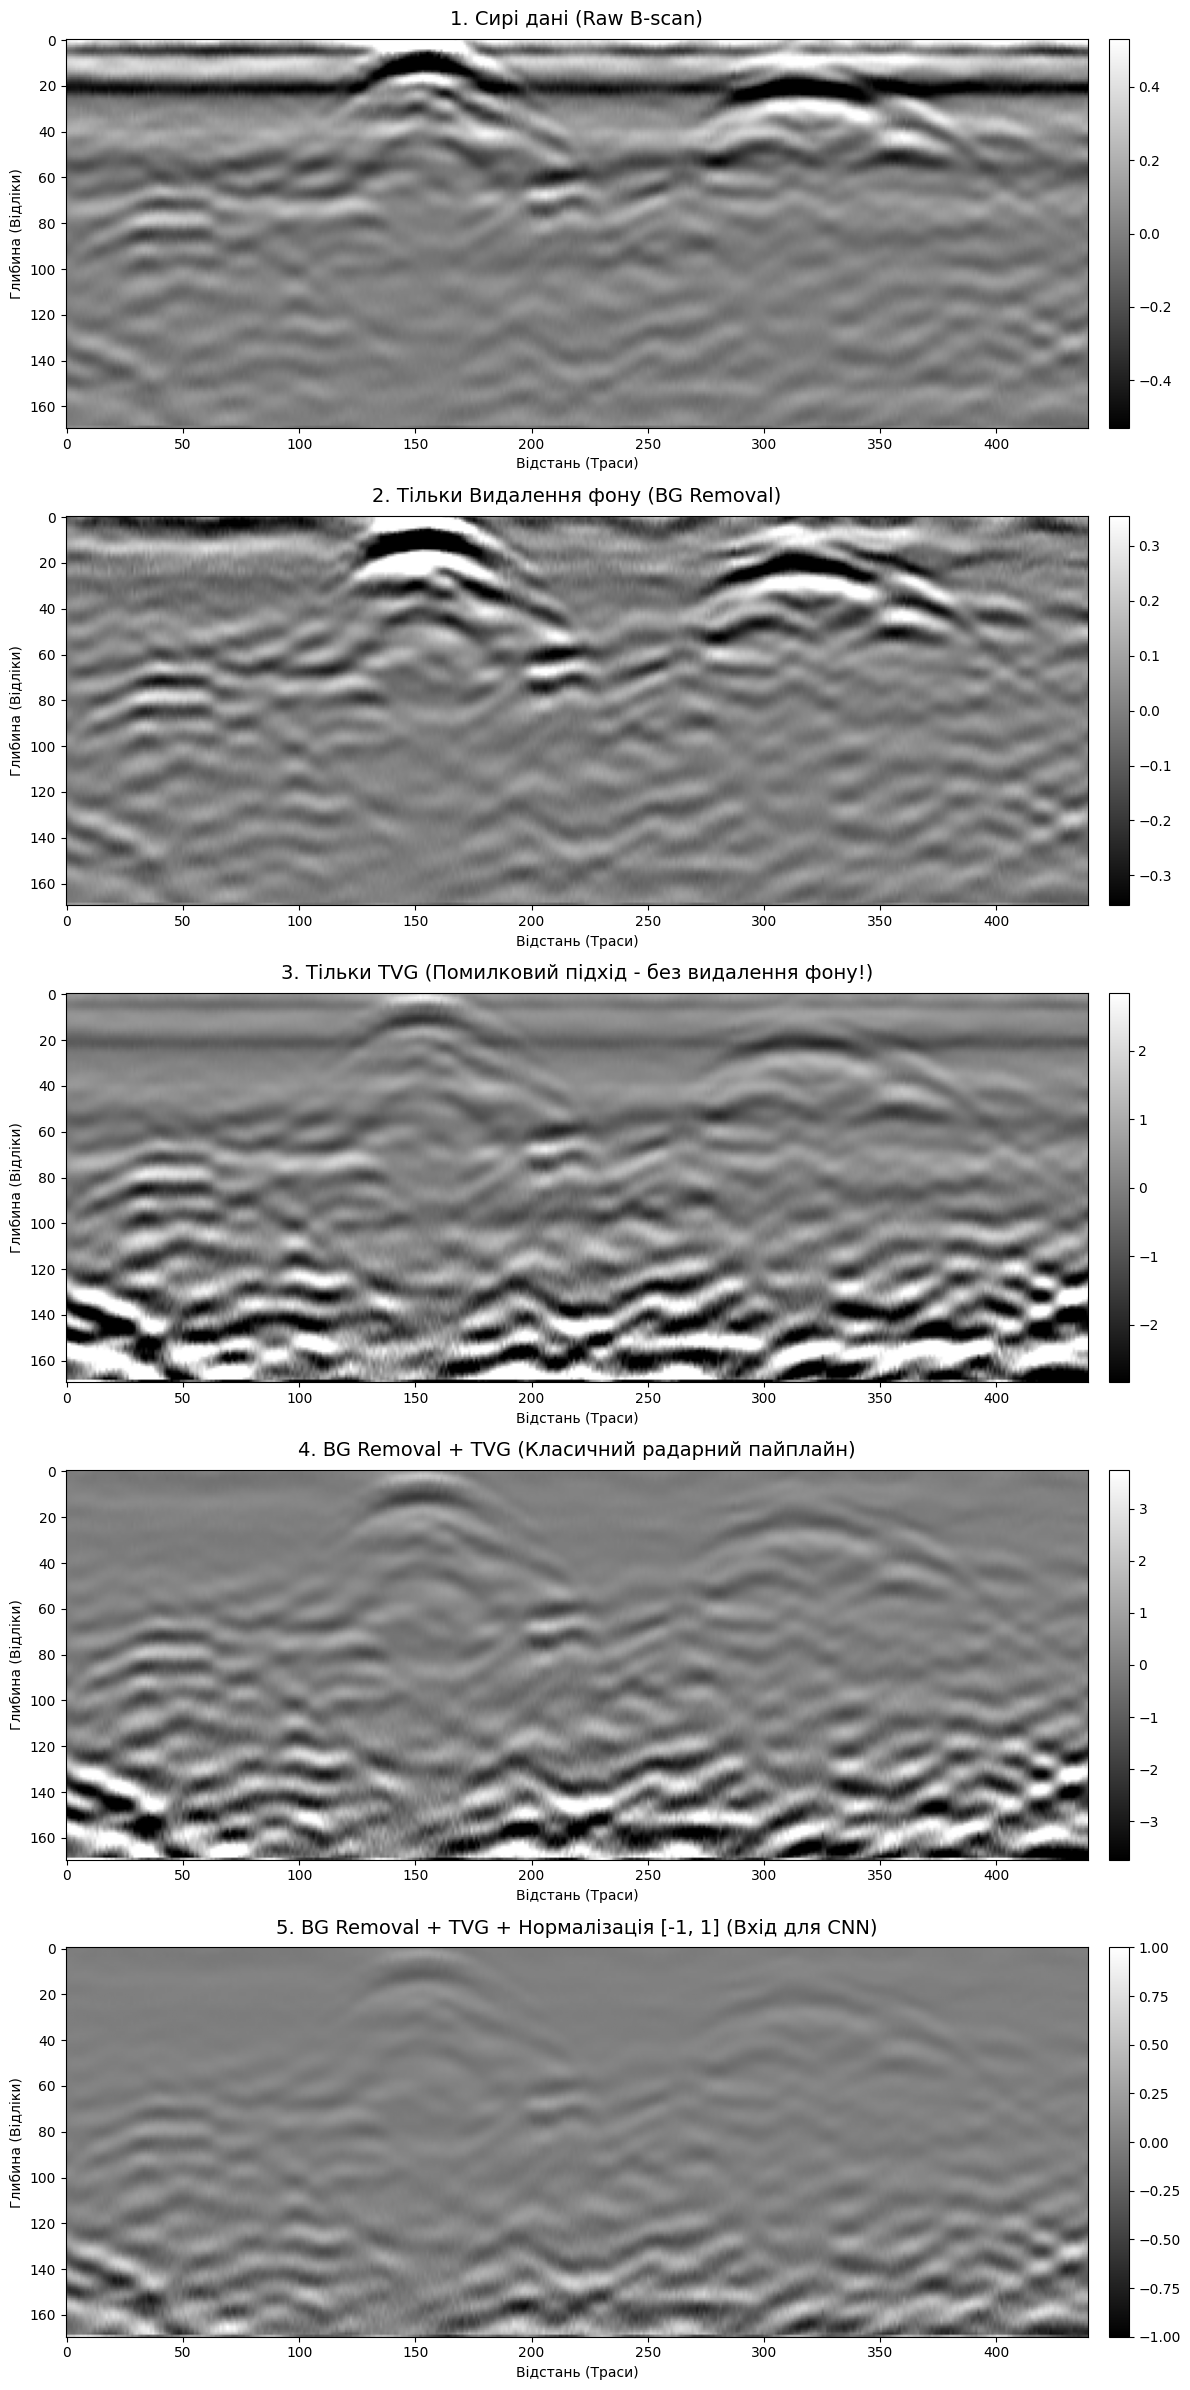

In [61]:
line_idx = 33
raw = data[line_idx].copy()

# ==========================================
# ПІДГОТОВКА КОМПОНЕНТІВ
# ==========================================
# 1. Компонент видалення фону (середня траса)
mean_trace = np.mean(raw, axis=1, keepdims=True)

# 2. Компонент компенсації загасання (TVG)
alpha = 0.025  # Коефіцієнт підсилення (можете поекспериментувати з 0.01 - 0.04)
depth_indices = np.arange(raw.shape[0])
gain_curve = np.exp(alpha * depth_indices).reshape(-1, 1)

# ==========================================
# ГЕНЕРАЦІЯ КОМБІНАЦІЙ
# ==========================================
# Комбінація 1: Сирі дані
# (вже є в змінній raw)

# Комбінація 2: Тільки видалення фону
bg_removed = raw - mean_trace

# Комбінація 3: Тільки TVG (Без видалення фону)
tvg_only = raw * gain_curve

# Комбінація 4: Видалення фону -> потім TVG (Правильний підхід)
bg_tvg = (raw - mean_trace) * gain_curve

# Комбінація 5: Видалення фону -> TVG -> Нормалізація (Для нейромережі)
max_val = np.max(np.abs(bg_tvg))
bg_tvg_norm = bg_tvg / max_val

# ==========================================
# ВІЗУАЛІЗАЦІЯ
# ==========================================
combinations = [
    ("1. Сирі дані (Raw B-scan)", raw),
    ("2. Тільки Видалення фону (BG Removal)", bg_removed),
    ("3. Тільки TVG (Помилковий підхід - без видалення фону!)", tvg_only),
    ("4. BG Removal + TVG (Класичний радарний пайплайн)", bg_tvg),
    ("5. BG Removal + TVG + Нормалізація [-1, 1] (Вхід для CNN)", bg_tvg_norm)
]

fig, axes = plt.subplots(5, 1, figsize=(12, 24))

for i, (title, scan_data) in enumerate(combinations):
    # Обчислення лімітів контрасту
    if i == 4:
        # Для нормалізованих даних ліміт завжди жорстко 1.0
        vmax = 1.0
    elif i == 2:
        # Для чистого TVG значення "відлітають" у космос через підсилення фону,
        # тому беремо жорсткіший перцентиль, щоб хоч щось побачити
        vmax = np.percentile(np.abs(scan_data), 95)
    else:
        vmax = np.percentile(np.abs(scan_data), 98)

    im = axes[i].imshow(scan_data, cmap='gray', aspect='auto', vmin=-vmax, vmax=vmax)
    axes[i].set_title(title, fontsize=14, pad=10)
    axes[i].set_xlabel("Відстань (Траси)")
    axes[i].set_ylabel("Глибина (Відліки)")
    fig.colorbar(im, ax=axes[i], fraction=0.02, pad=0.02)

plt.tight_layout()
plt.show()